## Tilted Plane Baseline Propagation ## 

This notebook aims to demonstrate a baseline propagation method between two tilted planes that is differentiable. We use an analytic solution of a gaussian beam propagating between two tilted planes as ground truth, and then solve the propagation integral using the Rayleigh-Sommerfeld formulation. A fourier transform based method - via fraunhofer, fresnel or the angular spectrum method is not yet implemented, but a possible solution in a paper and matlab code block is detailed also. 

In [1]:
import os

os.environ["JAX_ENABLE_X64"] = "1"
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.2' 

import jax
import jax.numpy as jnp
from jax_dataclasses import pytree_dataclass
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # ensures 3D
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_default_device", jax.devices("gpu")[0])
%matplotlib widget

## Create Functions ##

In [2]:
def gaussian(X_coords, Y_coords, x0=0.0, y0=0.0, w0x=1.0, w0y=1.0, r_curv_x=jnp.inf, r_curv_y=jnp.inf, wavelength=1.0):
    k = 2 * jnp.pi / wavelength

    q_inv_x = 1 / r_curv_x + 1j * wavelength / (jnp.pi * w0x**2)
    q_inv_y = 1 / r_curv_y + 1j * wavelength / (jnp.pi * w0y**2)

    E_field = jnp.exp(1j * k / 2 * ( (X_coords - x0)**2 * q_inv_x + (Y_coords - y0)**2 * q_inv_y ))

    return E_field


def zero_phase(u, idx_x, idx_y):
    u_centre = u[idx_x, idx_y]
    phase_difference = 0 - jnp.angle(u_centre)
    u_new = u * jnp.exp(1j * phase_difference)
    return u_new


def simpson2d(f, ax, bx, ay, by):
    """
    Parameters:
        f (jnp.ndarray): array of function values on an (..., Nx, Ny) grid.
        ax, bx (float): Integration bounds for x.
        ay, by (float): Integration bounds for y.

    Returns:
        jnp.ndarray: Approximate value of the integral with shape f.shape[:-2].
    """
    f = jnp.asarray(f)
    *batch_shape, num_x, num_y = f.shape

    def _simpson2d_single(f2d):
        # f2d has shape (num_x, num_y); num_x,num_y come from outer scope
        hx = (bx - ax) / (num_x - 1)
        hy = (by - ay) / (num_y - 1)

        idx_x = jnp.arange(num_x)
        idx_y = jnp.arange(num_y)

        w_x = jnp.where(
            (idx_x == 0) | (idx_x == num_x - 1),
            1.0,
            jnp.where(idx_x % 2 == 0, 2.0, 4.0)
        )
        w_y = jnp.where(
            (idx_y == 0) | (idx_y == num_y - 1),
            1.0,
            jnp.where(idx_y % 2 == 0, 2.0, 4.0)
        )

        w_2d = jnp.outer(w_x, w_y)
        return (hx * hy / 9.0) * jnp.sum(f2d * w_2d)

    if not batch_shape:
        return _simpson2d_single(f)

    vmapped = _simpson2d_single
    for _ in batch_shape[::-1]:
        vmapped = jax.vmap(vmapped)

    return vmapped(f)



def analytic_gaussian_propagation(
    Xp, Yp, Zp,
    x0, y0,
    w0x=0.3, w0y=0.3,
    r_curv_x=jnp.inf, r_curv_y=jnp.inf,
    wavelength=0.5
):
    k = 2 * jnp.pi / wavelength

    # initial q^{-1} exactly matching your source-plane definition
    q0x_inv = 1 / r_curv_x + 1j * wavelength / (jnp.pi * w0x**2)
    q0y_inv = 1 / r_curv_y + 1j * wavelength / (jnp.pi * w0y**2)

    q0x = 1.0 / q0x_inv     # complex
    q0y = 1.0 / q0y_inv

    # propagate along beam axis
    qx = q0x + Zp           # same shape as Zp
    qy = q0y + Zp

    # amplitude + Gouy phase factors
    Ax = jnp.sqrt(q0x / qx)
    Ay = jnp.sqrt(q0y / qy)

    # longitudinal phase
    phase_z = jnp.exp(1j * k * Zp)

    # transverse quadratic phases
    phase_x = jnp.exp(1j * k * (Xp - x0)**2 / (2.0 * qx))
    phase_y = jnp.exp(1j * k * (Yp - y0)**2 / (2.0 * qy))

    return Ax * Ay * phase_z * phase_x * phase_y

def to_beam_frame(XYZ, P_source):
    rel = XYZ - P_source.r0
    R = P_source.rotation_matrix
    return jnp.einsum('ij,...j->...i', R.T, rel)


def plot_plane(ax, Plane, XYZ, arrow_scale=0.5, axis_scale=1.0, plane_label=''):
    # Plot plane surface (wireframe)
    ax.plot_wireframe(
        XYZ[..., 0], XYZ[..., 1], XYZ[..., 2],
        color='k', linewidth=0.01, rstride=1, cstride=1
    )

    origin = Plane.r0
    scale = arrow_scale

    # Local axes
    ax.quiver(
        origin[0], origin[1], origin[2],
        Plane.e_u[0], Plane.e_u[1], Plane.e_u[2],
        length=scale, color='r'
    )
    ax.quiver(
        origin[0], origin[1], origin[2],
        Plane.e_v[0], Plane.e_v[1], Plane.e_v[2],
        length=scale, color='g'
    )
    ax.quiver(
        origin[0], origin[1], origin[2],
        Plane.n[0], Plane.n[1], Plane.n[2],
        length=scale, color='b'
    )

    # Add a 3D text label just beside the plane origin
    if plane_label:
        label_offset = 1.1 * scale * Plane.n  # shift slightly along normal
        label_pos = origin + label_offset
        ax.text(
            float(label_pos[0]),
            float(label_pos[1]),
            float(label_pos[2]),
            plane_label,
            color='k'
        )

    # Make plot nicer
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title("Tilted Plane with Local Coordinate Axes")

    ax.set_xlim([-axis_scale, axis_scale])
    ax.set_ylim([-axis_scale, axis_scale])
    ax.set_zlim([-axis_scale, axis_scale])


@pytree_dataclass
class Plane:
    r0: jnp.ndarray      
    e_u: jnp.ndarray     
    e_v: jnp.ndarray     
    n: jnp.ndarray       
    u_coords: jnp.ndarray
    v_coords: jnp.ndarray

    @classmethod
    def from_normal(cls, r0, n, u_coords, v_coords, x_pref=jnp.array([1.0, 0.0, 0.0])):
        n = n / jnp.linalg.norm(n)

        # make e_u by projecting x_pref onto the plane
        t = x_pref - jnp.dot(x_pref, n) * n
        e_u = t / jnp.linalg.norm(t)
        e_v = jnp.cross(n, e_u)

        return cls(r0=jnp.asarray(r0),
                   e_u=e_u,
                   e_v=e_v,
                   n=n,
                   u_coords=u_coords,
                   v_coords=v_coords)

    def point(self, u, v):
        """Return 3D point(s) corresponding to local (u,v) coordinates."""
        return self.r0 + u[..., None]*self.e_u + v[..., None]*self.e_v
    
    @property
    def rotation_matrix(self):
        """Return rotation matrix from plane frame to global frame."""
        return jnp.column_stack((self.e_u, self.e_v, self.n))
    
    @property
    def uv_coords_meshgrid(self):
        """Return meshgrid of (u,v) coordinates."""
        U, V = jnp.meshgrid(self.u_coords, self.v_coords, indexing='ij')
        return U, V

## Make 2 Tilted Planes - Source and Sample ##

In [3]:
tilt_source = -45 * jnp.pi/180
tilt_sample = 90 * jnp.pi/180

n_source = jnp.array([0.0, jnp.sin(tilt_source), jnp.cos(tilt_source)])
n_sample = jnp.array([0.0, jnp.sin(tilt_sample), jnp.cos(tilt_sample)])

uv_source_extent = 2e-1
uv_sample_extent = 2

n_coords = 256
u_source, v_source = jnp.linspace(-uv_source_extent/2, uv_source_extent/2, n_coords), jnp.linspace(-uv_source_extent/2, uv_source_extent/2, n_coords)
u_sample, v_sample = jnp.linspace(-uv_sample_extent/2, uv_sample_extent/2, n_coords), jnp.linspace(-uv_sample_extent/2, uv_sample_extent/2, n_coords)
U_sample, V_sample = jnp.meshgrid(u_sample, v_sample)
U_source, V_source = jnp.meshgrid(u_source, v_source)


P_source = Plane.from_normal(r0=jnp.array([0., 0., 0.]), n=n_source, u_coords=u_source, v_coords=v_source)
P_sample = Plane.from_normal(r0=jnp.array([0., -3.0, 3.0]), n=n_sample, u_coords=u_sample, v_coords=v_sample)

XYZ_source = P_source.point(U_source, V_source)
XYZ_sample = P_sample.point(U_sample, V_sample)

## Plot the tilted Planes for some sanity ##

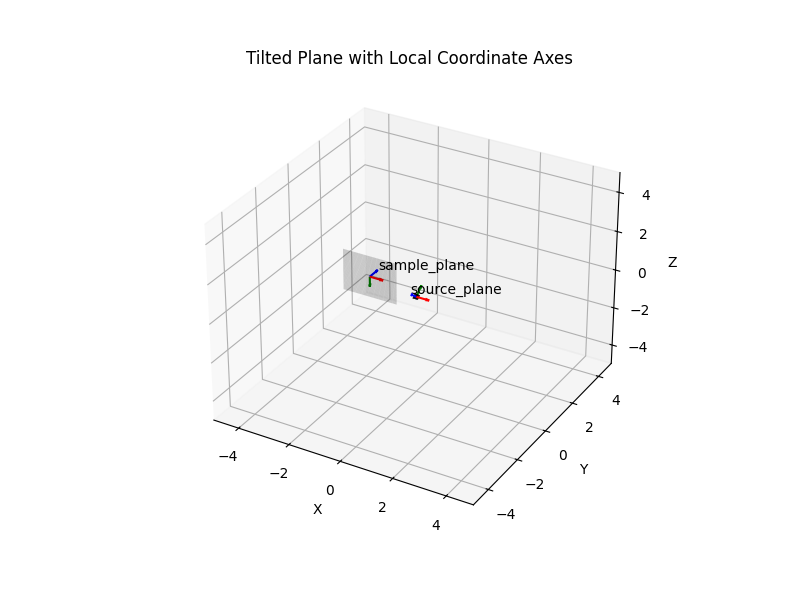

In [4]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

plot_plane(ax, P_source, XYZ_source, plane_label='source_plane', axis_scale=5)
plot_plane(ax, P_sample, XYZ_sample, plane_label='sample_plane', axis_scale=5)

## Create a Gaussian Beam on the Source Plane ##


In [5]:
w0x, w0y = 0.01, 0.01
wavelength = 1e-3
x0, y0 = 0e-2, 0e-2
gaussian_beam_source = gaussian(U_source, V_source, x0=x0, y0=y0, w0x=w0x, w0y=w0y, wavelength=wavelength)

# Evaluate the gaussian beam propagated from the sample plane to the source plane
coords_sample = to_beam_frame(XYZ_sample, P_source)
Xp = coords_sample[..., 0]
Yp = coords_sample[..., 1]
Zp = coords_sample[..., 2]

## 1. Analytic Propagation of Gaussian Beam to Sample Plane ##

In [6]:

analytic_solution = analytic_gaussian_propagation(
    Xp, Yp, Zp,
    x0=x0, y0=y0,
    w0x=w0x, w0y=w0y,
    wavelength=wavelength
)
analytic_solution = zero_phase(analytic_solution, n_coords//2, n_coords//2)
analytic_solution = analytic_solution / jnp.max(jnp.abs(analytic_solution))

# set phase to zero where amplitude is very small
amp = jnp.abs(analytic_solution)
phase = jnp.angle(analytic_solution)
masked_phase = jnp.where(amp < 1e-5, 0.0, phase)
analytic_solution = amp * jnp.exp(1j * masked_phase)

## 2. Rayleigh Sommerfeld Propagation ##

In [7]:
def compute_integral(U_in, P_source, P_sample, wavelength):
    """
    Compute Rayleigh–Sommerfeld propagation from P_source to P_sample
    using Simpson 2D quadrature over the source coordinates.

    Parameters
    ----------
    U_in : (Nv_s, Nu_s) complex array
        Field on the source plane sampled on (u_source, v_source).
    P_source : Plane
        Source plane object, with .u_coords, .v_coords, .uv_coords_meshgrid, .point, .n.
    P_sample : Plane
        Sample plane object, with .u_coords, .v_coords, .point.
    wavelength : float

    Returns
    -------
    field_out : (Nv_t, Nu_t) complex array
        Propagated field on the sample plane.
    """

    # ---------- Source coordinates & geometry ----------
    u_source = P_source.u_coords        # (Nu_s,)
    v_source = P_source.v_coords        # (Nv_s,)
    U_s, V_s = P_source.uv_coords_meshgrid   # (Nv_s, Nu_s)
    n_source = P_source.n               # (3,)

    # 3D positions of all source points (grid, not flattened)
    r_s_grid = P_source.point(U_s, V_s)      # (Nv_s, Nu_s, 3)

    # Simpson bounds in source coordinates
    ax, bx = u_source[0], u_source[-1]
    ay, by = v_source[0], v_source[-1]

    # ---------- Target coordinates & geometry ----------
    u_sample = P_sample.u_coords        # (Nu_t,)
    v_sample = P_sample.v_coords        # (Nv_t,)
    Nu_t = u_sample.shape[0]
    Nv_t = v_sample.shape[0]

    U_t, V_t = jnp.meshgrid(u_sample, v_sample, indexing="xy")  # (Nv_t, Nu_t)
    r_t_grid = P_sample.point(U_t, V_t)                         # (Nv_t, Nu_t, 3)

    # Flatten targets so we can vmap over a single axis
    r_t_flat = r_t_grid.reshape(-1, 3)                          # (Nv_t * Nu_t, 3)

    k = 2 * jnp.pi / wavelength

    def field_at_target(r_t):
        # Broadcast r_t over source grid
        R_vec = r_t[None, None, :] - r_s_grid
        R = jnp.linalg.norm(R_vec, axis=-1)

        cos_theta = jnp.einsum("...i,i->...", R_vec, n_source) / R

        # RS kernel on full source grid
        K = (cos_theta / (1j * wavelength)) * jnp.exp(1j * k * R) / (R**2)

        integrand = U_in * K

        # 2D Simpson over (u_source, v_source)
        return simpson2d(integrand, ax, bx, ay, by)

    # Vectorize over all target points
    field_flat = jax.vmap(field_at_target, in_axes=(0,))(r_t_flat)
    field_out = field_flat.reshape(Nv_t, Nu_t)

    return field_out

integral_jitted = jax.jit(compute_integral)
numerical_solution = integral_jitted(gaussian_beam_source, P_source, P_sample, wavelength).block_until_ready()
numerical_solution = zero_phase(numerical_solution, n_coords//2, n_coords//2)
numerical_solution = numerical_solution / jnp.max(jnp.abs(numerical_solution))

# set phase to zero where amplitude is very small
amp = jnp.abs(numerical_solution)
phase = jnp.angle(numerical_solution)
masked_phase = jnp.where(amp < 1e-5, 0.0, phase)
numerical_solution = amp * jnp.exp(1j * masked_phase)

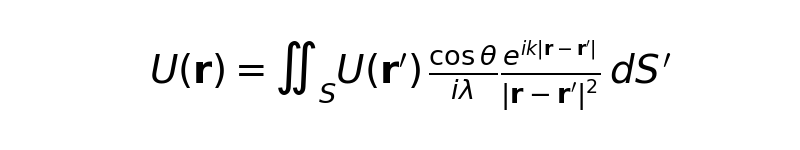

In [ ]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(8, 1.5))
ax.axis('off')

# Use a different font (e.g., 'DejaVu Serif') and try both dS' and dx\,dy
latex_eq_ds = (
    r"$U(\mathbf{r}) = \iint_{S} U(\mathbf{r}') \, "
    r"\frac{\cos\theta}{i \lambda} \frac{e^{ik|\mathbf{r} - \mathbf{r}'|}}{|\mathbf{r} - \mathbf{r}'|^2} \, dS'$"
)
latex_eq_dxdy = (
    r"$U(\mathbf{r}) = \iint U(\mathbf{r}') \, "
    r"\frac{\cos\theta}{i \lambda} \frac{e^{ik|\mathbf{r} - \mathbf{r}'|}}{|\mathbf{r} - \mathbf{r}'|^2} \, dx\,dy$"
)

# Show both for comparison
ax.text(0.5, 0.7, latex_eq_ds, fontsize=24, ha='center', va='center', fontname='DejaVu Serif')
ax.text(0.5, 0.3, latex_eq_dxdy, fontsize=24, ha='center', va='center', fontname='DejaVu Serif')
plt.show()

In [8]:
import timeit

start_time = timeit.default_timer()
integral_jitted(gaussian_beam_source, P_source, P_sample, wavelength).block_until_ready()
end_time = timeit.default_timer()
print(f"Propagation time: {end_time - start_time:.4f} seconds")

Propagation time: 0.4037 seconds


## 3. Angular Spectrum Rearrangement Propagation or NUFFT Method ##

https://github.com/Hao-Laboratory/Angular-spectrum-rearrangement/blob/main/ScalarDiffraction/ScalarDiffraction_ASR_AP.m

https://opg.optica.org/optica/fulltext.cfm?uri=optica-12-1-39

## Comparison Plots ##

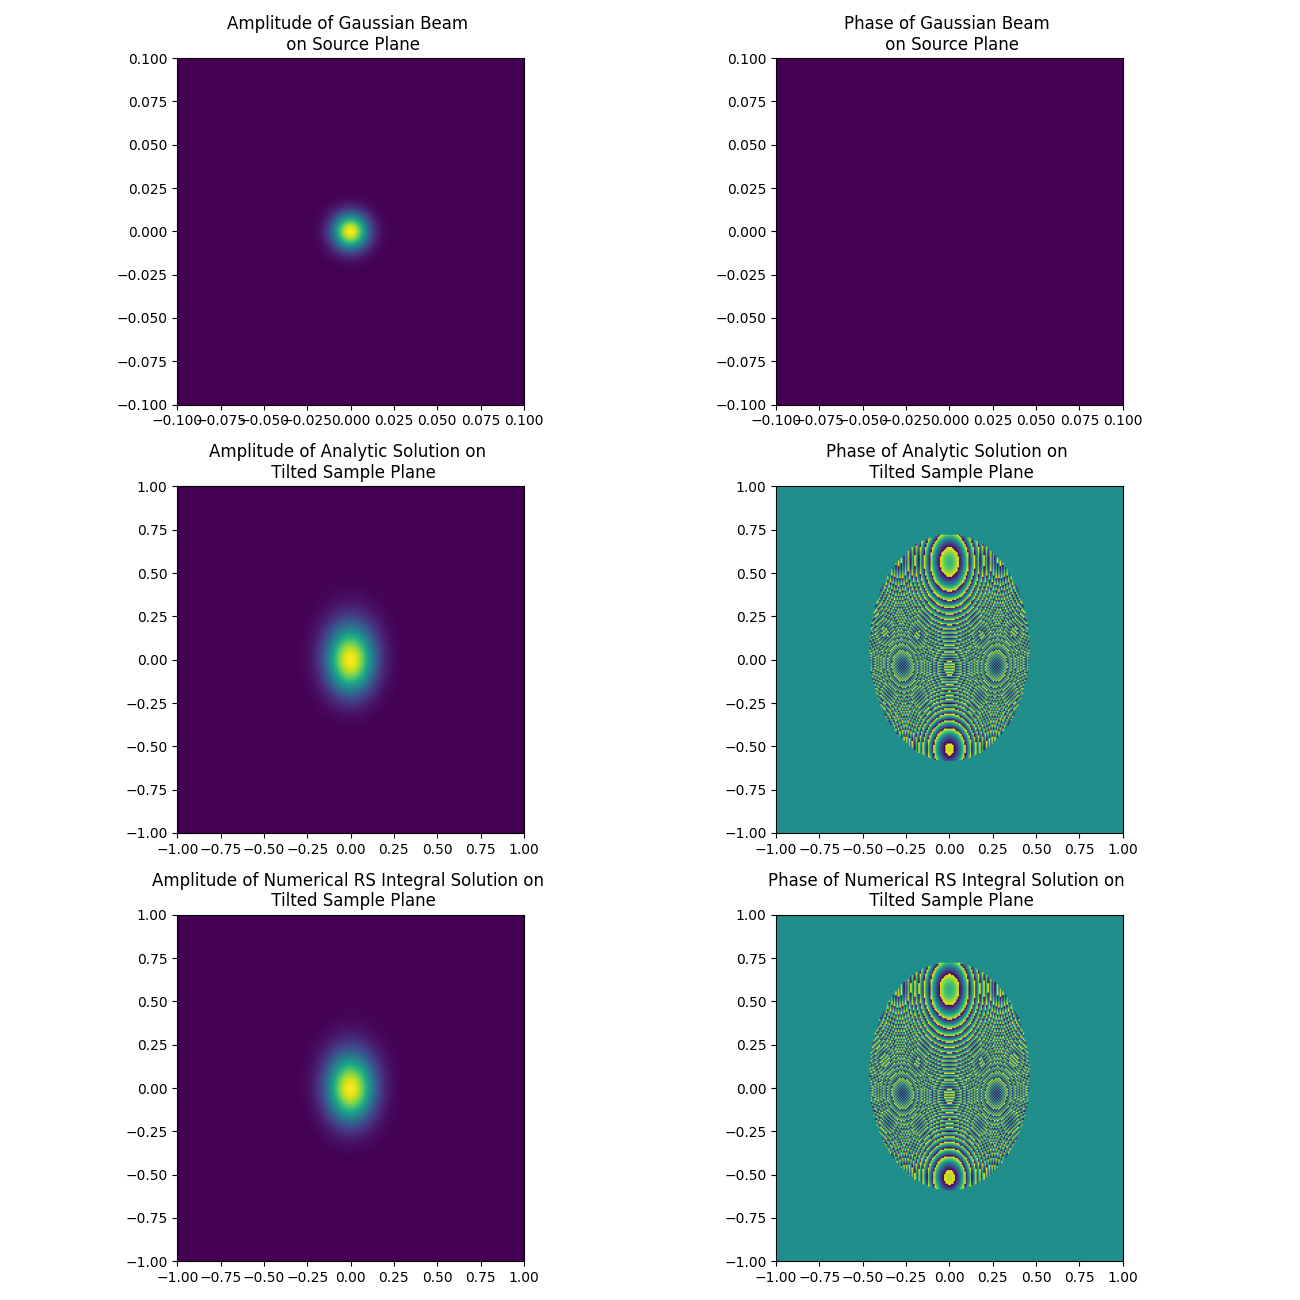

In [9]:
fig, axs = plt.subplots(3, 2, figsize=(13,13))
axs[0, 0].imshow(jnp.abs(gaussian_beam_source), extent=(-uv_source_extent/2, uv_source_extent/2, -uv_source_extent/2, uv_source_extent/2))
axs[0, 0].set_title("Amplitude of Gaussian Beam \n on Source Plane")
axs[0, 1].imshow(jnp.angle(gaussian_beam_source), extent=(-uv_source_extent/2, uv_source_extent/2, -uv_source_extent/2, uv_source_extent/2))
axs[0, 1].set_title("Phase of Gaussian Beam \n on Source Plane")
axs[1, 0].imshow(jnp.abs(analytic_solution), extent=(-uv_sample_extent/2, uv_sample_extent/2, -uv_sample_extent/2, uv_sample_extent/2))
axs[1, 0].set_title("Amplitude of Analytic Solution on \n Tilted Sample Plane")
axs[1, 1].imshow(jnp.angle(analytic_solution), extent=(-uv_sample_extent/2, uv_sample_extent/2, -uv_sample_extent/2, uv_sample_extent/2))
axs[1, 1].set_title("Phase of Analytic Solution on \n Tilted Sample Plane")
axs[2, 0].imshow(jnp.abs(numerical_solution), extent=(-uv_sample_extent/2, uv_sample_extent/2, -uv_sample_extent/2, uv_sample_extent/2))
axs[2, 0].set_title("Amplitude of Numerical RS Integral Solution on \n Tilted Sample Plane")
axs[2, 1].imshow(jnp.angle(numerical_solution), extent=(-uv_sample_extent/2, uv_sample_extent/2, -uv_sample_extent/2, uv_sample_extent/2))
axs[2, 1].set_title("Phase of Numerical RS Integral Solution on \n Tilted Sample Plane")

# overlay mask contour
plt.tight_layout()

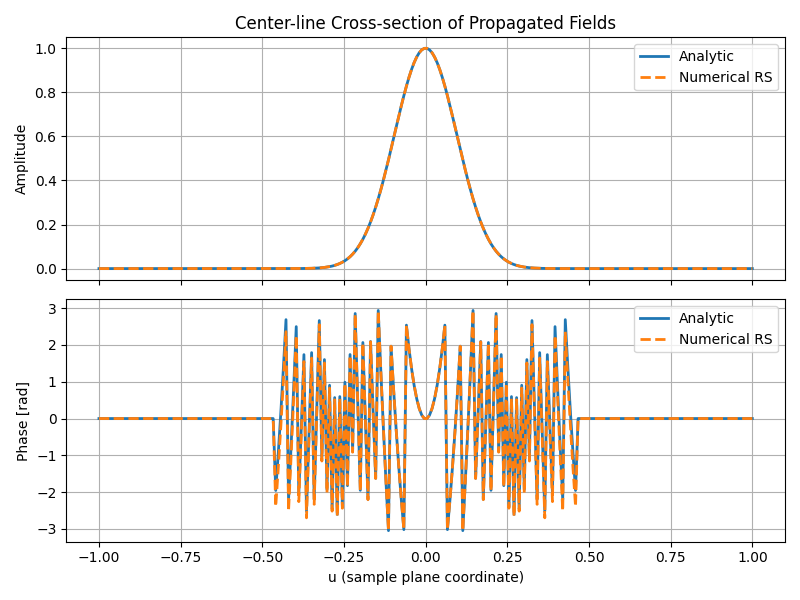

In [10]:
# take a 1D cross-section through the center (along u / x axis)
idx_mid = n_coords // 2

u_line = u_sample  # x-axis for the cross-section (same for both fields)

analytic_amp = jnp.abs(analytic_solution[idx_mid, :])
analytic_phase = jnp.angle(analytic_solution[idx_mid, :])

numerical_amp = jnp.abs(numerical_solution[idx_mid, :])
numerical_phase = jnp.angle(numerical_solution[idx_mid, :])

fig_cs, axs_cs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# Amplitude cross-section
axs_cs[0].plot(u_line, analytic_amp, label="Analytic", lw=2)
axs_cs[0].plot(u_line, numerical_amp, "--", label="Numerical RS", lw=2)
axs_cs[0].set_ylabel("Amplitude")
axs_cs[0].set_title("Center-line Cross-section of Propagated Fields")
axs_cs[0].legend()
axs_cs[0].grid(True)

# Phase cross-section
axs_cs[1].plot(u_line, analytic_phase, label="Analytic", lw=2)
axs_cs[1].plot(u_line, numerical_phase, "--", label="Numerical RS", lw=2)
axs_cs[1].set_xlabel("u (sample plane coordinate)")
axs_cs[1].set_ylabel("Phase [rad]")
axs_cs[1].legend()
axs_cs[1].grid(True)

plt.tight_layout()

## 5. Test another propagation from this plane to a detector ##

In [11]:
tilt_detector = 0 * jnp.pi/180

n_detector = jnp.array([0.0, jnp.sin(tilt_detector), jnp.cos(tilt_detector)])

uv_det_extent = 50e-1

n_coords = 1024
uv_det_extent = jnp.linspace(-uv_det_extent/2, uv_det_extent/2, n_coords)
U_det, V_det = jnp.meshgrid(uv_det_extent, uv_det_extent)
P_det = Plane.from_normal(r0=jnp.array([0., 0.0, 10]), n=n_detector, u_coords=uv_det_extent, v_coords=uv_det_extent)

XYZ_detector = P_det.point(U_det, V_det)


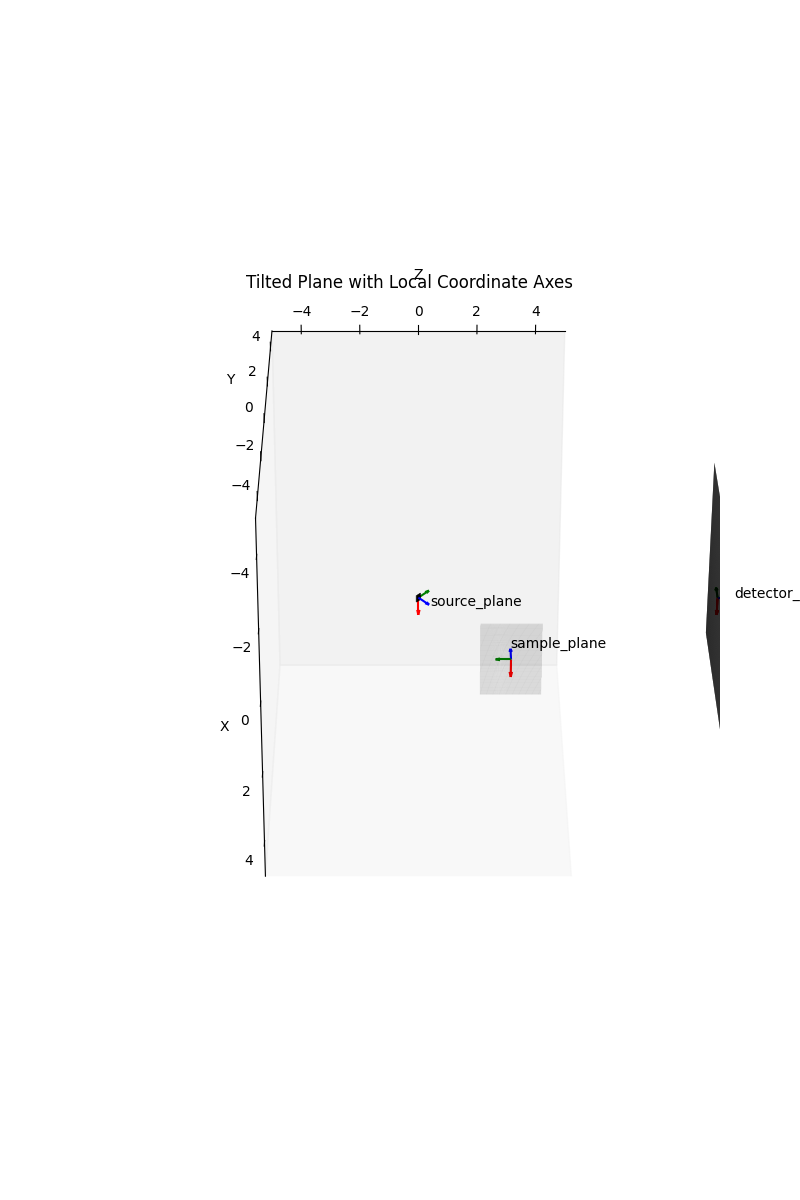

In [25]:
fig = plt.figure(figsize=(8, 12))
ax = fig.add_subplot(111, projection='3d')

plot_plane(ax, P_source, XYZ_source, plane_label='source_plane', axis_scale=5)
plot_plane(ax, P_sample, XYZ_sample, plane_label='sample_plane', axis_scale=5)
plot_plane(ax, P_det, XYZ_detector, plane_label='detector_plane', axis_scale=5)

# Hide grid lines and axis background
ax.grid(False)
ax.set_facecolor('white')

# Set the view so that source is on the right and detector is on the left upright
ax.view_init(elev=0, azim=-120, roll = -90)

## 6. Propagation from Sample to Detector with Beam Steering

To ensure the beam hits the detector (which might not be in the specular reflection path), we model the sample as a mirror that imparts a specific phase gradient. This "steers" the beam from the incident direction vector to the target detector vector.

We calculate the phase ramp $\Delta \Phi(u, v)$ such that the outgoing wavefront creates a k-vector pointing towards the detector center.

Steering applied:
  Incident Dir: [ 0.         -0.70710678  0.70710678]
  Target Dir:   [0.         0.3939193  0.91914503]
  Delta k_u:    0.00 rad/m
  Delta k_v:    -1332.28 rad/m
Propagating to detector...
Propagation complete.


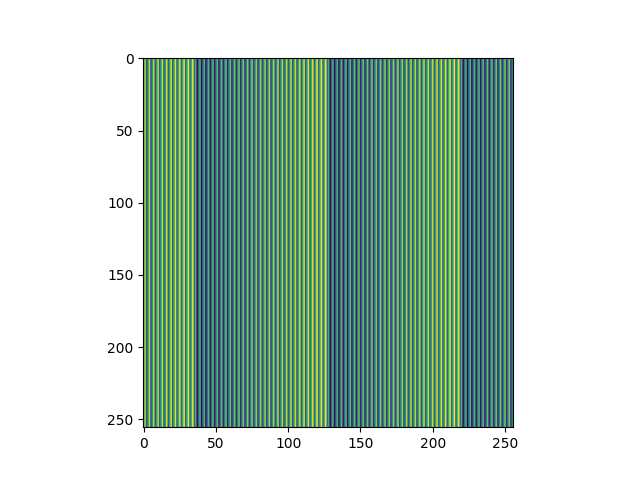

In [13]:
def deflect_beam_to_detector(U_in, P_source, P_sample, P_det, wavelength):
    """
    Apply a linear phase ramp to U_in (on P_sample) to steer the beam 
    from the incidence direction (P_source -> P_sample) 
    to the target direction (P_sample -> P_det).
    
    This ensures the beam shape (curvature) is maintained, while the
    propagation direction is redirected towards the detector.
    """
    k = 2 * jnp.pi / wavelength
    
    # 1. Calculate Geometry Vectors
    # Vector from Source to Sample (Incident Direction)
    vec_in = P_sample.r0 - P_source.r0
    u_in = vec_in / jnp.linalg.norm(vec_in)
    
    # Vector from Sample to Detector (Target Direction)
    vec_out = P_det.r0 - P_sample.r0
    u_out = vec_out / jnp.linalg.norm(vec_out)
    
    # 2. Calculate the Phase Gradient needed
    # We want to change the k-vector from k * u_in to k * u_out.
    # The phase difference required is delta_k * r
    # delta_k = k * (u_out - u_in)
    
    # We project this change onto the sample plane coordinates (u, v)
    dku = k * jnp.dot(u_out - u_in, P_sample.e_u)
    dkv = k * jnp.dot(u_out - u_in, P_sample.e_v)
    
    # 3. Apply the Linear Phase Ramp
    # U_out(u,v) = U_in(u,v) * exp(i * (dku * u + dkv * v))
    UU, VV = P_sample.uv_coords_meshgrid
    phase_ramp = dku * UU + dkv * VV
    steering_phasor = jnp.exp(1j * phase_ramp)

    plt.figure()
    plt.imshow(jnp.angle(steering_phasor))
    
    U_out = U_in * steering_phasor
    
    print(f"Steering applied:")
    print(f"  Incident Dir: {u_in}")
    print(f"  Target Dir:   {u_out}")
    print(f"  Delta k_u:    {dku:.2f} rad/m")
    print(f"  Delta k_v:    {dkv:.2f} rad/m")
    
    return U_out

# Apply steering
# Note: 'numerical_solution' is the field on P_sample calculated in Step 2.
U_sample_steered = deflect_beam_to_detector(numerical_solution, P_source, P_sample, P_det, wavelength)

# Propagate to Detector Plane
# We treat the sample plane as the new source, and propagate to P_det
print("Propagating to detector...")
U_detector = integral_jitted(U_sample_steered, P_sample, P_det, wavelength).block_until_ready()

# Normalize for plotting
U_detector_norm = zero_phase(U_detector, n_coords//2, n_coords//2)
U_detector_norm = U_detector_norm / jnp.max(jnp.abs(U_detector_norm))

print("Propagation complete.")

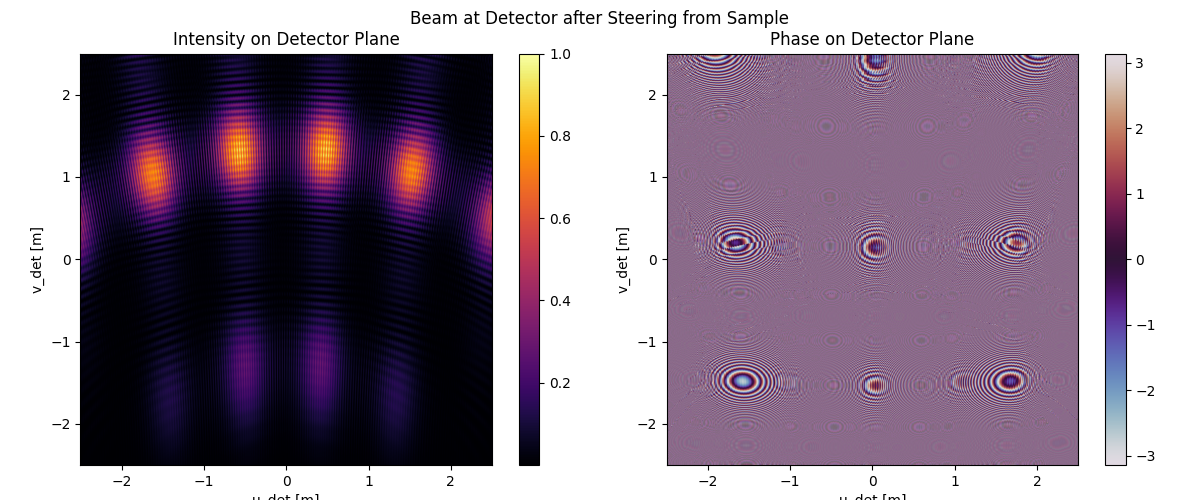

In [14]:
# Plot the result on the Detector Plane
fig_det, ax_det = plt.subplots(1, 2, figsize=(12, 5))

# Intensity
im0 = ax_det[0].imshow(
    jnp.abs(U_detector_norm)**2, 
    extent=[P_det.u_coords[0], P_det.u_coords[-1], P_det.v_coords[0], P_det.v_coords[-1]],
    origin='lower', cmap='inferno'
)
ax_det[0].set_title("Intensity on Detector Plane")
ax_det[0].set_xlabel("u_det [m]")
ax_det[0].set_ylabel("v_det [m]")
plt.colorbar(im0, ax=ax_det[0])

# Phase
im1 = ax_det[1].imshow(
    jnp.angle(U_detector_norm), 
    extent=[P_det.u_coords[0], P_det.u_coords[-1], P_det.v_coords[0], P_det.v_coords[-1]],
    origin='lower', cmap='twilight'
)
ax_det[1].set_title("Phase on Detector Plane")
ax_det[1].set_xlabel("u_det [m]")
ax_det[1].set_ylabel("v_det [m]")
plt.colorbar(im1, ax=ax_det[1])

plt.suptitle("Beam at Detector after Steering from Sample")
plt.tight_layout()
plt.show()